## ⚙️ Imports & Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

PALETTE = ['#4361EE','#3A0CA3','#7209B7','#F72585','#4CC9F0']
sns.set_theme(style='whitegrid', palette=PALETTE)
print("TensorFlow version:", tf.__version__)


2026-05-17 14:32:18.706691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779028338.930983      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779028338.996766      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779028339.544690      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779028339.544754      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779028339.544757      16 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


---
## 📊 Task 1 — Data Exploration

In [2]:
df = pd.read_csv('/kaggle/input/datasets/prathamtripathi/drug-classification/drug200.csv')
print("Shape:", df.shape)
df.head()


Shape: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [3]:
# Dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [4]:
# Statistical summary
df.describe()


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [5]:
# Missing values
print("Missing values:\n", df.isnull().sum())
print("\nDrug distribution:\n", df['Drug'].value_counts())


Missing values:
 Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Drug distribution:
 Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [6]:
# Identify feature types
print("Numerical features  : Age, Na_to_K")
print("Categorical features: Sex, BP, Cholesterol")
print("Target variable     : Drug (5 classes)")


Numerical features  : Age, Na_to_K
Categorical features: Sex, BP, Cholesterol
Target variable     : Drug (5 classes)


### Visualizations

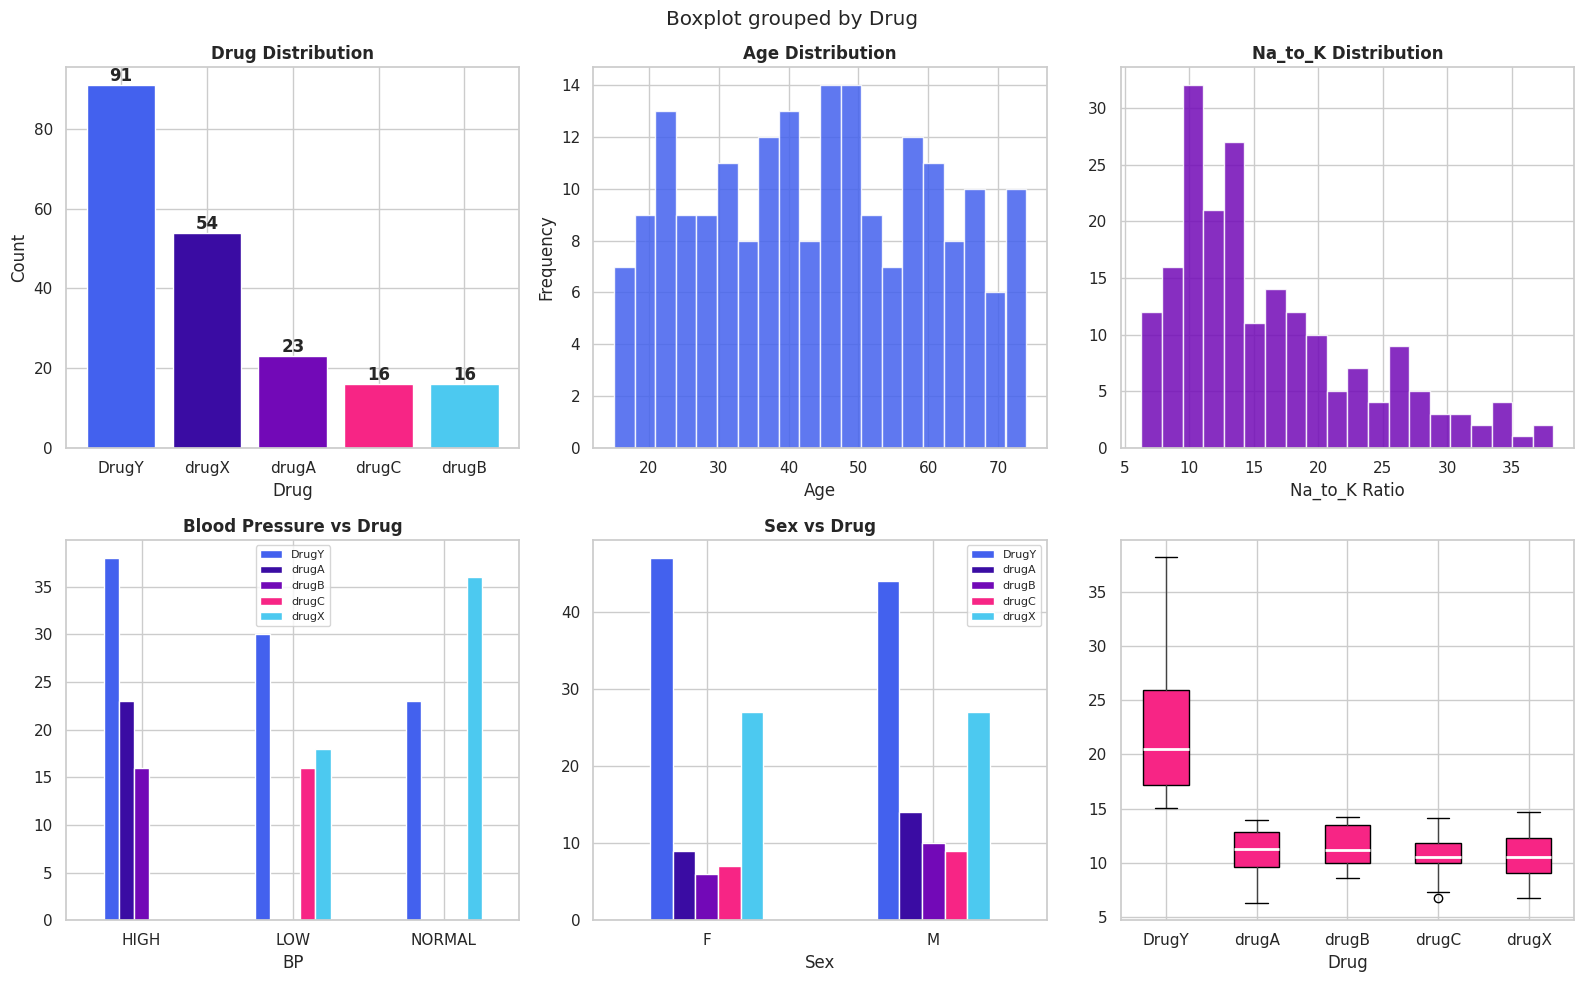

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Drug Classification — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Drug distribution
counts = df['Drug'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=PALETTE)
axes[0,0].set_title('Drug Distribution', fontweight='bold')
axes[0,0].set_xlabel('Drug'); axes[0,0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v+1, str(v), ha='center', fontweight='bold')

# Age distribution
axes[0,1].hist(df['Age'], bins=20, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0,1].set_title('Age Distribution', fontweight='bold')
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Frequency')

# Na_to_K distribution
axes[0,2].hist(df['Na_to_K'], bins=20, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[0,2].set_title('Na_to_K Distribution', fontweight='bold')
axes[0,2].set_xlabel('Na_to_K Ratio')

# BP vs Drug
pd.crosstab(df['BP'], df['Drug']).plot(kind='bar', ax=axes[1,0], color=PALETTE, edgecolor='white')
axes[1,0].set_title('Blood Pressure vs Drug', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0); axes[1,0].legend(fontsize=8)

# Sex vs Drug
pd.crosstab(df['Sex'], df['Drug']).plot(kind='bar', ax=axes[1,1], color=PALETTE, edgecolor='white')
axes[1,1].set_title('Sex vs Drug', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0); axes[1,1].legend(fontsize=8)

# Na_to_K boxplot per drug
df.boxplot(column='Na_to_K', by='Drug', ax=axes[1,2],
           patch_artist=True,
           boxprops=dict(facecolor=PALETTE[3], color='black'),
           medianprops=dict(color='white', linewidth=2))
axes[1,2].set_title('Na_to_K by Drug', fontweight='bold')
plt.sca(axes[1,2]); plt.title('')

plt.tight_layout()
plt.show()


---
## 🔧 Task 2 — Data Preprocessing

In [8]:
df_enc = df.copy()

# Label encode categorical features
le_sex  = LabelEncoder(); df_enc['Sex']         = le_sex.fit_transform(df['Sex'])
le_bp   = LabelEncoder(); df_enc['BP']          = le_bp.fit_transform(df['BP'])
le_chol = LabelEncoder(); df_enc['Cholesterol'] = le_chol.fit_transform(df['Cholesterol'])
le_drug = LabelEncoder(); df_enc['Drug']        = le_drug.fit_transform(df['Drug'])

print("Sex encodings     :", dict(zip(le_sex.classes_,   le_sex.transform(le_sex.classes_))))
print("BP encodings      :", dict(zip(le_bp.classes_,    le_bp.transform(le_bp.classes_))))
print("Cholesterol enc.  :", dict(zip(le_chol.classes_,  le_chol.transform(le_chol.classes_))))
print("Drug encodings    :", dict(zip(le_drug.classes_,  le_drug.transform(le_drug.classes_))))

df_enc.head()


Sex encodings     : {'F': np.int64(0), 'M': np.int64(1)}
BP encodings      : {'HIGH': np.int64(0), 'LOW': np.int64(1), 'NORMAL': np.int64(2)}
Cholesterol enc.  : {'HIGH': np.int64(0), 'NORMAL': np.int64(1)}
Drug encodings    : {'DrugY': np.int64(0), 'drugA': np.int64(1), 'drugB': np.int64(2), 'drugC': np.int64(3), 'drugX': np.int64(4)}


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [9]:
# Features and target
X = df_enc.drop('Drug', axis=1).values
y = df_enc['Drug'].values
num_classes = len(np.unique(y))

# Normalize numerical features: Age (col 0) and Na_to_K (col 4)
scaler = StandardScaler()
X_scaled = X.copy().astype(float)
X_scaled[:, [0, 4]] = scaler.fit_transform(X[:, [0, 4]])

# One-hot encode target
y_cat = to_categorical(y, num_classes=num_classes)

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y)

print(f"Train samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")
print(f"Features      : {X_train.shape[1]}")
print(f"Classes       : {num_classes}  → {list(le_drug.classes_)}")


Train samples : 160
Test  samples : 40
Features      : 5
Classes       : 5  → ['DrugY', 'drugA', 'drugB', 'drugC', 'drugX']


---
## 🧠 Task 3 — Artificial Neural Network (ANN)

### Architecture
```
Input(5) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.2) → Dense(16, ReLU) → Dense(5, Softmax)
```

In [10]:
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
], name='ANN')

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ann.summary()


2026-05-17 14:32:44.743338: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,077 (12.02 KB)

 Trainable params: 3,077 (12.02 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_ann = ann.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.1229 - loss: 1.7632 - val_accuracy: 0.0312 - val_loss: 1.6521
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1851 - loss: 1.6238 - val_accuracy: 0.0938 - val_loss: 1.5845
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2971 - loss: 1.5396 - val_accuracy: 0.4688 - val_loss: 1.5201
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5281 - loss: 1.4530 - val_accuracy: 0.6562 - val_loss: 1.4590
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5725 - loss: 1.4005 - val_accuracy: 0.5000 - val_loss: 1.4014
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6696 - loss: 1.2845 - val_accuracy: 0.4375 - val_loss: 1.3459
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6686 - loss: 1.2065 - val_accuracy: 0.4375 - val_loss: 1.2937
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6223 - loss: 1.1275 - val_accuracy: 0.4688 - val_loss: 1.

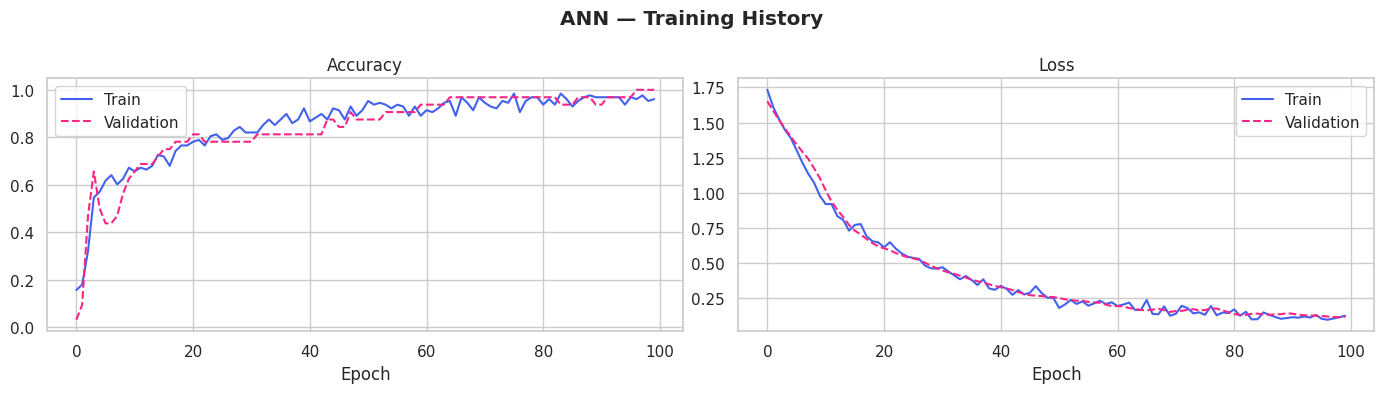

In [12]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ANN — Training History', fontweight='bold')

axes[0].plot(history_ann.history['accuracy'],     color=PALETTE[0], label='Train')
axes[0].plot(history_ann.history['val_accuracy'], color=PALETTE[3], linestyle='--', label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_ann.history['loss'],     color=PALETTE[0], label='Train')
axes[1].plot(history_ann.history['val_loss'], color=PALETTE[3], linestyle='--', label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
ANN Test Accuracy: 0.9500 (95.00%)

              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      0.67      0.80         3
       drugX       0.91      0.91      0.91        11

    accuracy                           0.95        40
   macro avg       0.97      0.92      0.94        40
weighted avg       0.95      0.95      0.95        40



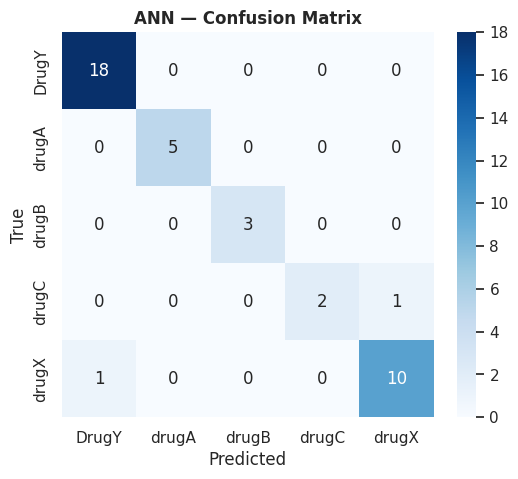

In [13]:
# Evaluation
y_pred_ann = np.argmax(ann.predict(X_test), axis=1)
y_true     = np.argmax(y_test, axis=1)
ann_acc    = accuracy_score(y_true, y_pred_ann)

print(f"ANN Test Accuracy: {ann_acc:.4f} ({ann_acc:.2%})\n")
print(classification_report(y_true, y_pred_ann, target_names=le_drug.classes_))

# Confusion Matrix
cm_ann = confusion_matrix(y_true, y_pred_ann)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_drug.classes_, yticklabels=le_drug.classes_)
plt.title('ANN — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()


---
## 🔁 Task 4 — Recurrent Neural Network (RNN)

In [14]:
# Reshape for RNN: (samples, timesteps=5, features=1)
X_train_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_rnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)
print("RNN input shape:", X_train_rnn.shape)


RNN input shape: (160, 5, 1)


In [15]:
rnn = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=True),
    SimpleRNN(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
], name='RNN')

rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn.summary()


Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 5, 64)          │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,941 (31.02 KB)

 Trainable params: 7,941 (31.02 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_rnn = rnn.fit(
    X_train_rnn, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.3296 - loss: 1.4952 - val_accuracy: 0.3125 - val_loss: 1.4253
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5286 - loss: 1.2503 - val_accuracy: 0.3125 - val_loss: 1.3696
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5498 - loss: 1.1365 - val_accuracy: 0.3438 - val_loss: 1.2177
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5791 - loss: 1.0912 - val_accuracy: 0.6562 - val_loss: 1.0947
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6629 - loss: 0.9703 - val_accuracy: 0.6562 - val_loss: 1.0289
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7351 - loss: 0.8802 - val_accuracy: 0.6562 - val_loss: 0.9385
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7208 - loss: 0.8439 - val_accuracy: 0.7812 - val_loss: 0.8675
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7495 - loss: 0.7324 - val_accuracy: 0.7500 - val_loss:

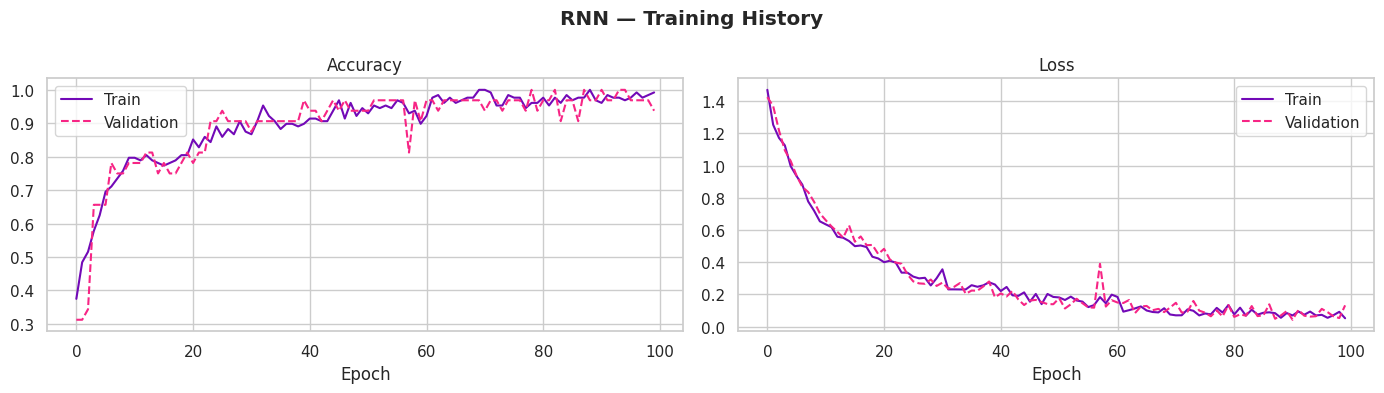

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('RNN — Training History', fontweight='bold')

axes[0].plot(history_rnn.history['accuracy'],     color=PALETTE[2], label='Train')
axes[0].plot(history_rnn.history['val_accuracy'], color=PALETTE[3], linestyle='--', label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_rnn.history['loss'],     color=PALETTE[2], label='Train')
axes[1].plot(history_rnn.history['val_loss'], color=PALETTE[3], linestyle='--', label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
RNN Test Accuracy: 0.9250 (92.50%)

              precision    recall  f1-score   support

       DrugY       1.00      0.83      0.91        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       0.79      1.00      0.88        11

    accuracy                           0.93        40
   macro avg       0.96      0.97      0.96        40
weighted avg       0.94      0.93      0.93        40



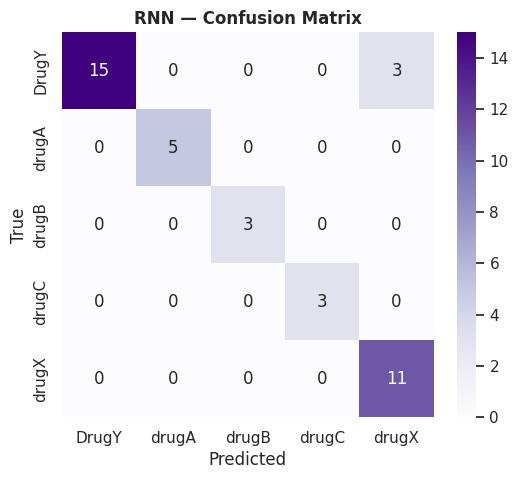

In [18]:
# Evaluation
y_pred_rnn = np.argmax(rnn.predict(X_test_rnn), axis=1)
rnn_acc    = accuracy_score(y_true, y_pred_rnn)

print(f"RNN Test Accuracy: {rnn_acc:.4f} ({rnn_acc:.2%})\n")
print(classification_report(y_true, y_pred_rnn, target_names=le_drug.classes_))

# Confusion Matrix
cm_rnn = confusion_matrix(y_true, y_pred_rnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_drug.classes_, yticklabels=le_drug.classes_)
plt.title('RNN — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()


---
## ⚖️ Task 5 — Model Comparison

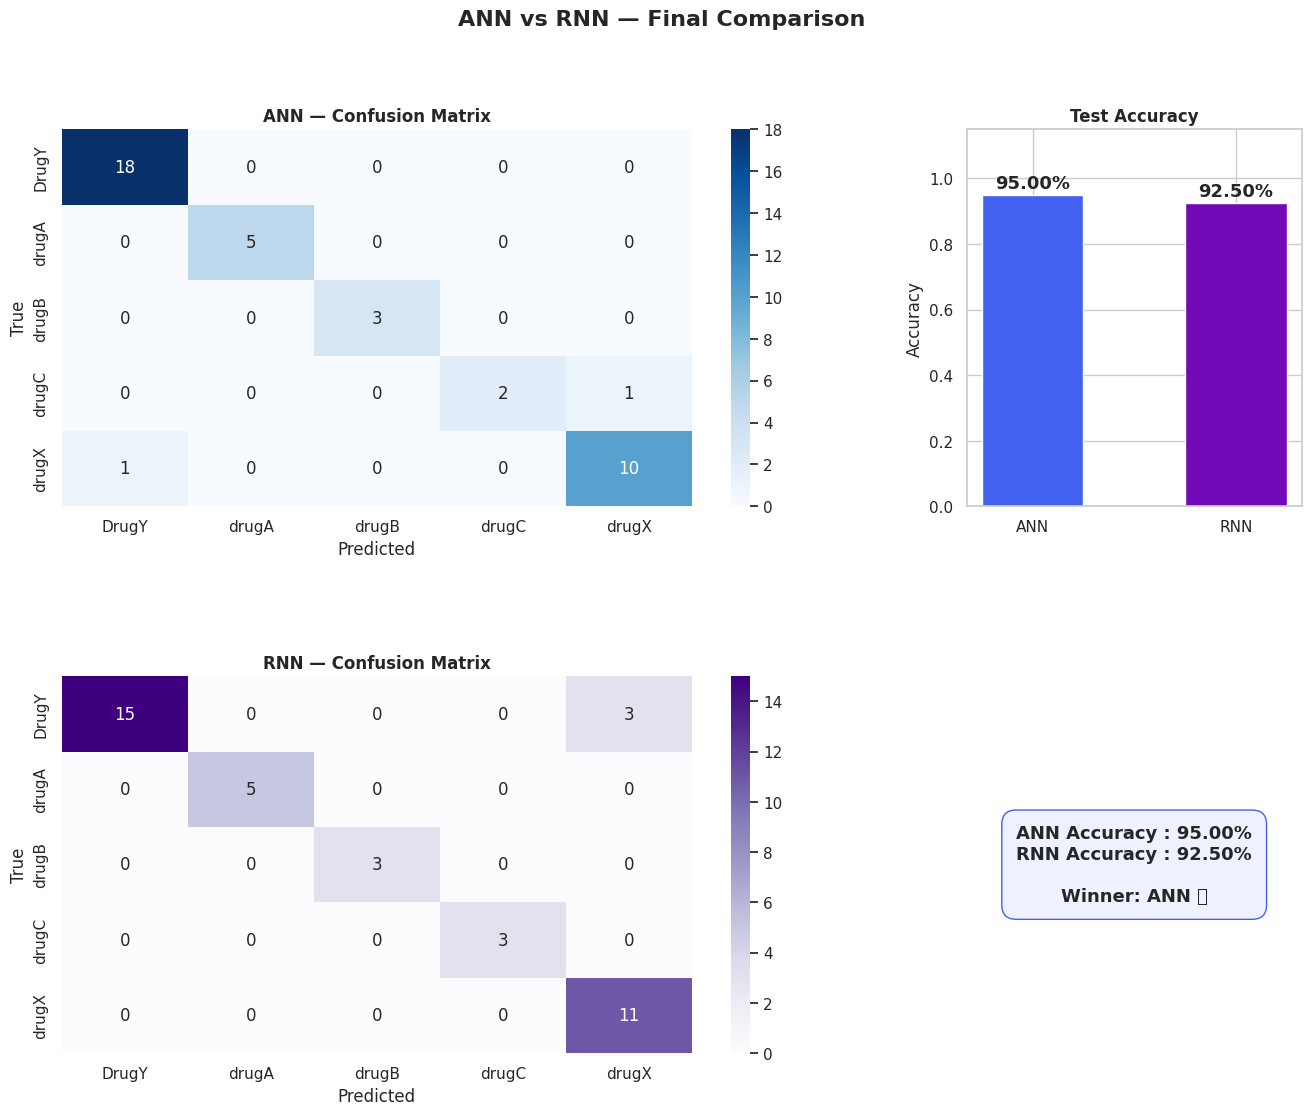

In [19]:
# Side-by-side confusion matrices + accuracy bar
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('ANN vs RNN — Final Comparison', fontsize=16, fontweight='bold')

# Confusion matrix ANN
ax1 = fig.add_subplot(gs[0, 0:2])
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=le_drug.classes_, yticklabels=le_drug.classes_)
ax1.set_title('ANN — Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# Confusion matrix RNN
ax2 = fig.add_subplot(gs[1, 0:2])
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Purples', ax=ax2,
            xticklabels=le_drug.classes_, yticklabels=le_drug.classes_)
ax2.set_title('RNN — Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

# Accuracy bar comparison
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(['ANN', 'RNN'], [ann_acc, rnn_acc], color=[PALETTE[0], PALETTE[2]],
               edgecolor='white', width=0.5)
ax3.set_ylim(0, 1.15); ax3.set_title('Test Accuracy', fontweight='bold')
ax3.set_ylabel('Accuracy')
for bar, val in zip(bars, [ann_acc, rnn_acc]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.2%}', ha='center', fontweight='bold', fontsize=13)

# Summary text box
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
winner = 'ANN' if ann_acc >= rnn_acc else 'RNN'
summary = f"ANN Accuracy : {ann_acc:.2%}\nRNN Accuracy : {rnn_acc:.2%}\n\nWinner: {winner} 🏆"
ax4.text(0.5, 0.5, summary, ha='center', va='center', fontsize=13, fontweight='bold',
         transform=ax4.transAxes,
         bbox=dict(facecolor='#EEF2FF', edgecolor='#4361EE', boxstyle='round,pad=0.8'))

plt.show()


In [20]:
# Comparison table
print("=" * 45)
print(f"{'Model':<10} {'Test Accuracy':>15} {'Params':>10}")
print("-" * 45)
print(f"{'ANN':<10} {ann_acc:>14.2%} {ann.count_params():>10,}")
print(f"{'RNN':<10} {rnn_acc:>14.2%} {rnn.count_params():>10,}")
print("=" * 45)
print(f"\nWinner ▶ {winner}")


Model        Test Accuracy     Params
---------------------------------------------
ANN                95.00%      3,077
RNN                92.50%      7,941

Winner ▶ ANN
